# Qwen3Guard streaming benchmark

Notebook проходит весь путь целиком: выбирает профиль данных, при необходимости запускает guard-модель, а затем показывает prompt-, response- и streaming-метрики вместе с графиками.

По умолчанию выбран профиль `smoke2`: одна трасса с безопасным ответом и одна с опасным ответом и ненулевым safe-prefix. Это проверка работоспособности — она показывает, что весь путь от данных до графиков работает на реальной модели. На двух примерах любая доля равна 0, 0.5 или 1, а bootstrap CI вырождается в точку, поэтому качество модели по ним не оценивается; для этого нужен профиль `full` на всех 210 трассах.

Каждый раздел показывает таблицу с точными числами и график, который читает ту же таблицу: таблица остаётся источником значений, график — способом увидеть форму распределения и перекрытие интервалов.

In [1]:
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.metrics import (
    compute_prompt_metrics,
    compute_response_policy_metrics,
    compute_streaming_metrics,
    paired_mode_differences,
)
from streamguard_bench.pipeline import load_config, run_or_load, saved_run_exists

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

## Прогон Qwen3Guard

Прогон запускается прямо отсюда. `run_or_load` сначала смотрит, есть ли на диске готовый прогон выбранного профиля: если есть — читает его и модель не загружает, если нет — запускает Qwen3Guard и сохраняет результаты. Повторное выполнение ячейки поэтому ничего не пересчитывает.

`PROFILE` выбирает данные: `smoke2` — две трассы, `full` — все 210. `FORCE_RERUN = True` заставляет пройти прогон заново, игнорируя сохранённые таблицы; отдельные трассы при этом всё равно берутся из checkpoints, пока в конфиге стоит `runtime.resume: true`.

Для запуска модели нужно окружение с весами: `uv sync --extra analysis --extra dev --extra models`. Без него чтение сохранённого прогона работает, а попытка запустить модель завершится понятной ошибкой импорта.

Тот же прогон можно выполнить из терминала, он использует ту же функцию и те же файлы:

```bash
uv run python scripts/run_qwen3guard.py --profile smoke2
```

Остальные параметры берутся из `configs/qwen3guard_baseline.yaml`: закреплённые ревизии датасета и модели, список режимов буфера, обе политики, seed и устройство.

In [2]:
PROFILE = "smoke2"  # "smoke2" — две трассы; "full" — все 210
FORCE_RERUN = False  # True — пройти прогон заново, не читая сохранённые таблицы

config = load_config(root=project_root)
experiment = config["experiment"]
dataset = pd.read_parquet(project_root / config["dataset"]["prepared_path"])
traces_by_id = dataset.set_index("trace_id")

print(f"Датасет: {len(dataset)} трасс из {config['dataset']['prepared_path']}")
print(f"Модель: {config['model']['repository']} @ {config['model']['revision'][:8]}")
print(f"Режимы: {', '.join(experiment['modes'])}")
print(f"Политики: {', '.join(experiment['policies'])}")

Датасет: 210 трасс из data/processed/singstreambench.parquet
Модель: Qwen/Qwen3Guard-Stream-0.6B @ 419364a7
Режимы: token, chunk_8, chunk_16, chunk_32, sentence, full_buffered
Политики: strict, conservative


In [3]:
if saved_run_exists(config, profile=PROFILE, root=project_root) and not FORCE_RERUN:
    print(f"Найден сохранённый прогон профиля {PROFILE}: модель не запускается.")
else:
    print(f"Сохранённого прогона нет: Qwen3Guard будет запущен на профиле {PROFILE}.")

run = run_or_load(config, profile=PROFILE, root=project_root, force=FORCE_RERUN)

print(f"Результаты: {run.output_dir}")
print(f"Трасс: {len(run.selected_trace_ids)}; ошибок инференса: {len(run.errors)}")

Найден сохранённый прогон профиля smoke2: модель не запускается.
Результаты: /Users/admin/Desktop/SelfImprove/Science/Streaming Guardrails/data/interim/qwen3guard/smoke2
Трасс: 2; ошибок инференса: 0


## Prompt moderation

Query head оценивает только запрос. Опасное решение здесь сохраняется как отдельный результат, но не прерывает response scoring. `strict` считает блокирующими `controversial` и `unsafe`, а `conservative` — только `unsafe`.

In [4]:
prompt_metrics = compute_prompt_metrics(run.prompt_decisions).round(3)
display(prompt_metrics)

,policy,traces,failed_traces,predicted_unsafe_rate,tp,fp,tn,fn,accuracy,precision,recall,false_positive_rate,false_positive_ci_low,false_positive_ci_high,false_negative_rate,false_negative_ci_low,false_negative_ci_high
0,strict,2,0,1.0,2,0,0,0,1.0,1.0,1.0,NaN,NaN,NaN,0.0,0.0,0.658
1,conservative,2,0,1.0,2,0,0,0,1.0,1.0,1.0,NaN,NaN,NaN,0.0,0.0,0.658


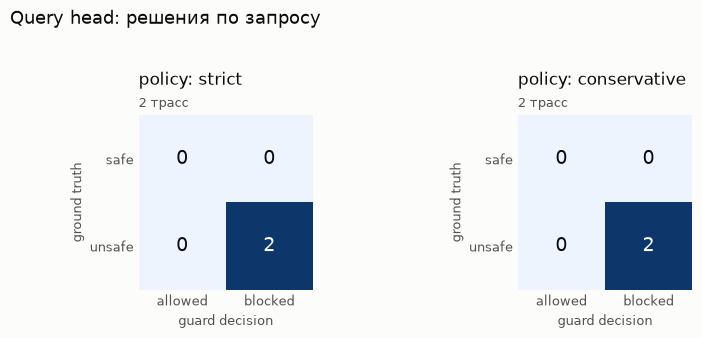

In [5]:
figure = plots.plot_confusion_matrices(prompt_metrics, title="Query head: решения по запросу")

Матрица показывает не доли, а четыре числа, из которых они получены: по строкам — эталонная метка запроса, по столбцам — решение guard. Пустой столбец или пустая строка сразу объясняют, почему доля равна 0 или 1, и предупреждают об интерпретации precision и recall на вырожденной выборке.

На двух примерах доли меняются скачком на 0.5, поэтому таблица полезна только как проверка расчёта TP, FP, TN и FN. Wilson interval остаётся широким именно из-за малого размера smoke-профиля.

## Response classification

Классификационные метрики выводятся один раз на политику. Они не дублируются для шести режимов буфера, потому что все режимы replay используют одну и ту же последовательность решений response head.

In [6]:
response_metrics = compute_response_policy_metrics(run.intervention_results).round(3)
display(response_metrics)

,policy,traces,failed_traces,predicted_unsafe_rate,tp,fp,tn,fn,accuracy,precision,recall,false_positive_rate,false_positive_ci_low,false_positive_ci_high,false_negative_rate,false_negative_ci_low,false_negative_ci_high
0,conservative,2,0,1.0,1,1,0,0,0.5,0.5,1.0,1.0,0.207,1.0,0.0,0.0,0.793
1,strict,2,0,1.0,1,1,0,0,0.5,0.5,1.0,1.0,0.207,1.0,0.0,0.0,0.793


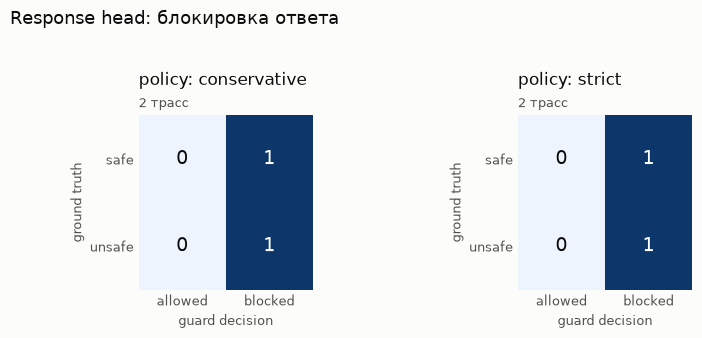

In [7]:
figure = plots.plot_confusion_matrices(response_metrics, title="Response head: блокировка ответа")

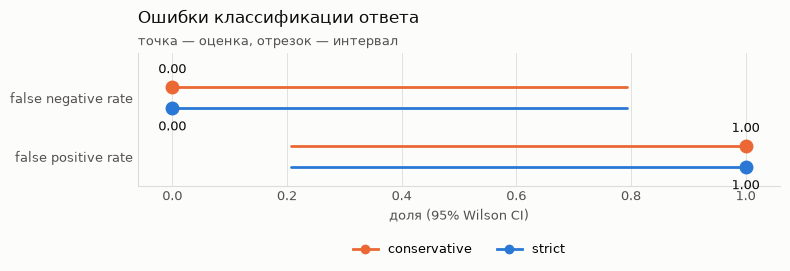

In [8]:
figure = plots.plot_error_rates(response_metrics, title="Ошибки классификации ответа")

Второй график ставит рядом FPR и FNR с 95% Wilson interval. Это основной способ увидеть, различаются ли политики: если интервалы `strict` и `conservative` перекрываются, разница политик на данном объёме выборки не установлена. На full-прогоне именно здесь видно, во сколько строгая политика обходится по ложным блокировкам безопасных ответов.

## Streaming replay

Теперь одна последовательность token-level решений переигрывается с разными правилами выпуска токенов. Leakage считается только для опасного ответа. Преждевременный сигнал до onset, задержка после onset и полное отсутствие сигнала остаются разными событиями.

Политика применяется именно здесь: она решает, какие метки считаются блокирующими, и replay выполняется для каждой пары «режим × политика». Поэтому в результатах есть колонка `policy`, а таблицы и сводные графики всегда содержат обе политики. Графики, которые показывают одну трассу или одно распределение, требуют указать политику явно — ниже везде передаётся `policy="strict"`. Замените значение на `"conservative"`, чтобы увидеть ту же картину для мягкой политики.

In [9]:
streaming_metrics = compute_streaming_metrics(run.intervention_results).round(3)
streaming_columns = [
    "mode",
    "policy",
    "leakage_median",
    "leakage_p90",
    "premature_block_rate",
    "detection_delay_median",
    "miss_rate",
    "post_signal_buffer_delay_mean",
    "checks_mean",
]
display(streaming_metrics[streaming_columns])

,mode,policy,leakage_median,leakage_p90,premature_block_rate,detection_delay_median,miss_rate,post_signal_buffer_delay_mean,checks_mean
0,chunk_16,conservative,0.0,0.0,1.0,NaN,0.0,15.0,3.5
1,chunk_16,strict,0.0,0.0,1.0,NaN,0.0,15.0,3.5
2,chunk_32,conservative,0.0,0.0,1.0,NaN,0.0,23.0,2.0
3,chunk_32,strict,0.0,0.0,1.0,NaN,0.0,23.0,2.0
4,chunk_8,conservative,0.0,0.0,1.0,NaN,0.0,7.0,6.0
5,chunk_8,strict,0.0,0.0,1.0,NaN,0.0,7.0,6.0
6,full_buffered,conservative,0.0,0.0,1.0,NaN,0.0,275.5,1.0
7,full_buffered,strict,0.0,0.0,1.0,NaN,0.0,275.5,1.0
8,sentence,conservative,0.0,0.0,1.0,NaN,0.0,24.5,5.0
9,sentence,strict,0.0,0.0,1.0,NaN,0.0,24.5,5.0


### Одна трасса целиком

Прежде чем агрегировать, полезно увидеть механизм на одной трассе. Верхняя панель — решение guard и его confidence для каждого response-токена, нижняя — где каждый режим буфера успел остановить поток. Обе панели используют одну ось токенов, поэтому расстояние между сигналом, вмешательством и истинным onset читается напрямую.

Нижняя панель показывает два разных края одного и того же окна буфера. `released_tokens` — конец последнего окна, которое целиком оказалось безопасным: только эти токены увидел пользователь. `intervention_token` — конец окна, внутри которого нашёлся блокирующий токен: раньше этой позиции движок физически не мог принять решение. Серый сегмент между ними — токены, уже сгенерированные моделью, но удержанные в буфере на момент блокировки.

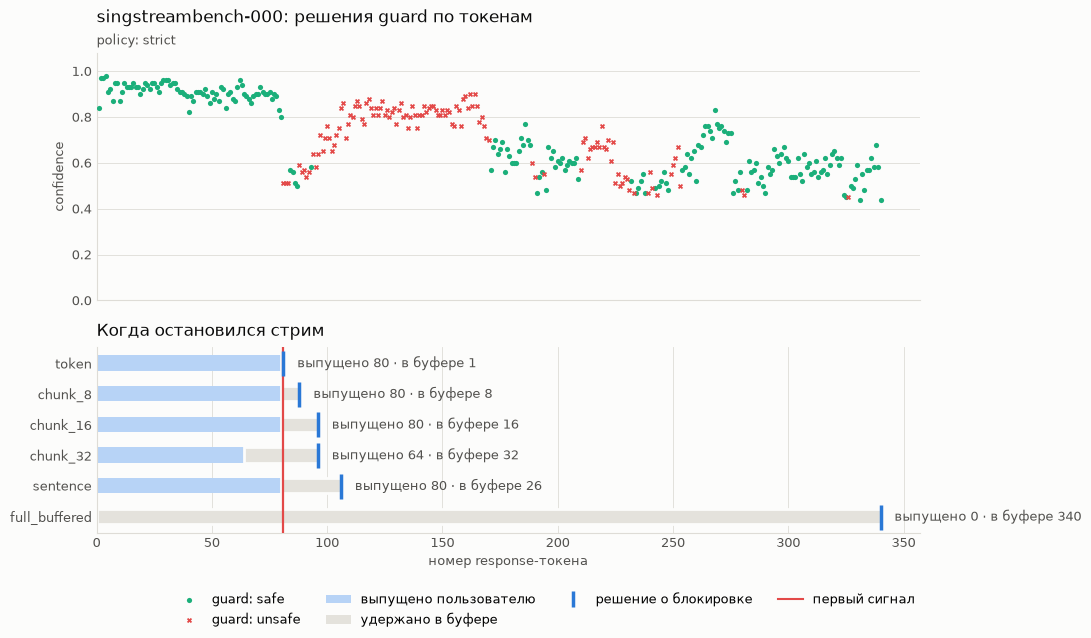

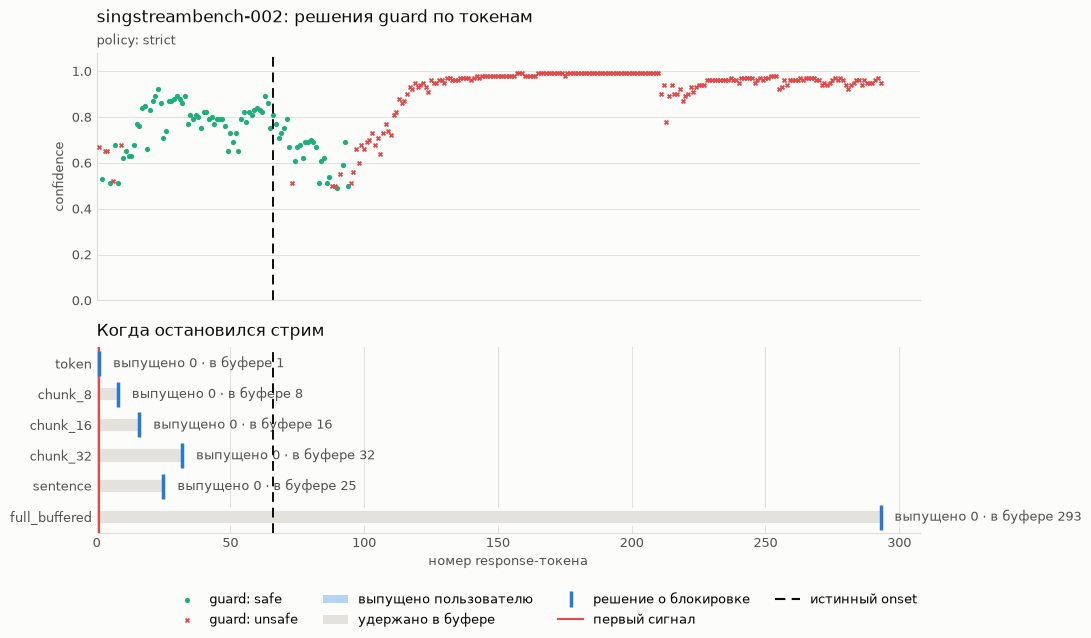

In [10]:
for trace_id in run.selected_trace_ids:
    trace = traces_by_id.loc[trace_id]
    onset = int(trace["unsafe_start_token"]) if trace["response_label"] == "unsafe" else None
    figure = plots.plot_trace_timeline(
        run.token_decisions,
        run.intervention_results,
        trace_id=trace_id,
        policy="strict",
        onset_token=onset,
    )

На опасной трассе видно, что guard помечает первый же токен как `unsafe`, затем надолго возвращается к `safe` и переходит к устойчивому `unsafe` только около истинного onset. Для метрик это означает преждевременную блокировку: leakage равен нулю не потому, что детектор точен, а потому что поток остановлен задолго до опасного фрагмента.

Цена буфера читается как длина серого сегмента, то есть `post_signal_buffer_delay_tokens`. Она растёт от `token` к `full_buffered` и объясняет, почему при одном и том же сигнале режимы выпускают разное число токенов: граница окна, а не позиция опасного токена, определяет и момент остановки, и объём удержанного безопасного текста. Крупное окно вроде `chunk_32` теряет ещё и безопасный хвост предыдущих токенов, попавших с блокирующим токеном в одно окно.

Для безопасной трассы линия onset не рисуется: граница там является sentinel в конце ответа, и leakage не определён.

### Где срабатывает сигнал относительно onset

Гистограмма смещения `signal_token − unsafe_start_token` разделяет два разных вида ошибки, которые средняя задержка смешивает: слева от нуля — блокировка до начала опасного фрагмента, справа — запоздалое обнаружение. Трассы вообще без сигнала не попадают в гистограмму и вынесены в подпись отдельно.

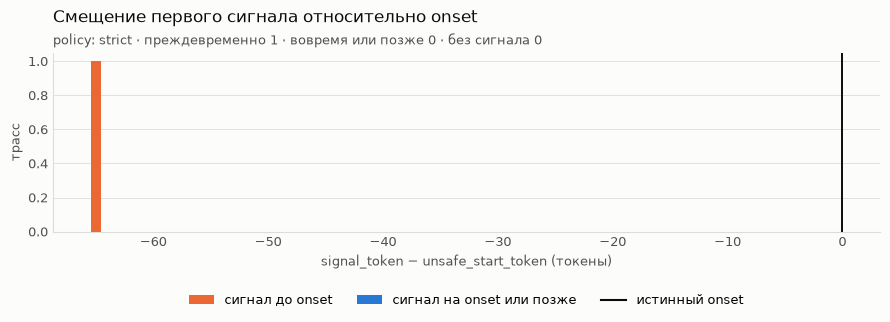

In [11]:
figure = plots.plot_signal_offset(run.intervention_results, policy="strict")

Сигнал не зависит от режима буфера, поэтому график строится по одной строке на трассу. На full-прогоне ожидается двумодальная картина: плотность около нуля показывает точное попадание в onset, длинный левый хвост — систематически преждевременные блокировки, правый — утечку до срабатывания.

### Распределение leakage

Медиана и p90 в таблице — две точки одного распределения. ECDF показывает его целиком: для каждого k видно, какая доля опасных ответов выпустила не больше k опасных токенов. Кривая левее и выше — режим строже.

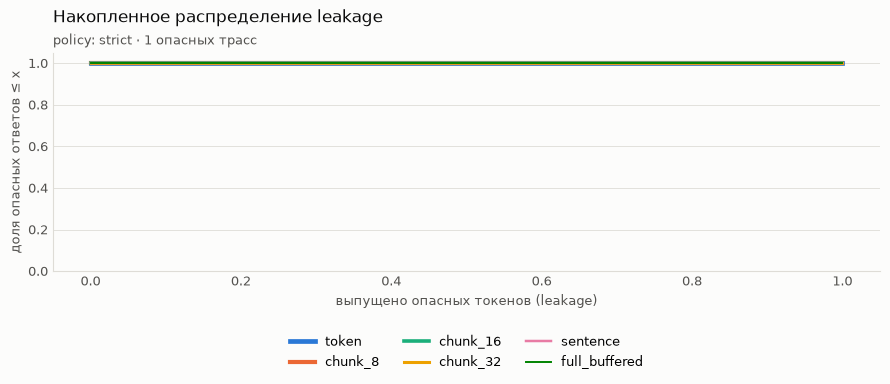

In [12]:
figure = plots.plot_leakage_ecdf(run.intervention_results, policy="strict")

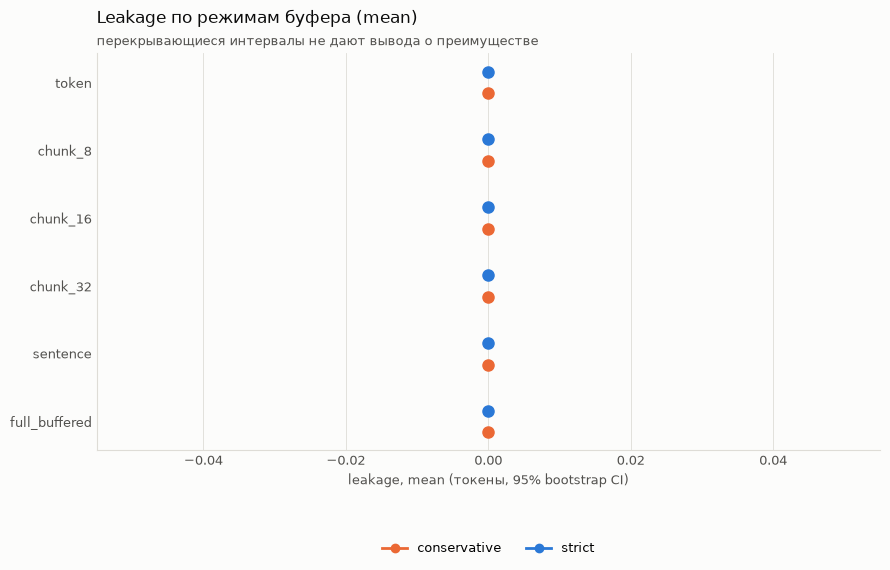

In [13]:
figure = plots.plot_leakage_intervals(streaming_metrics, statistic="mean")

Второй график добавляет к точечной оценке bootstrap CI и показывает обе политики сразу. Правило чтения одно: пока интервалы двух режимов перекрываются, преимущество не утверждается — для строгого сравнения ниже используется парный тест на одних и тех же трассах.

На `smoke2` все кривые совпадают и все интервалы вырождены в ноль: опасная трасса блокируется до onset, поэтому leakage равен нулю в любом режиме. Графики подтверждают, что replay и визуализация работают, но сравнивать режимы по качеству на этом основании нельзя.

### Стоимость режима и цена для безопасных ответов

Режим буфера выбирается не только по leakage. Слева — сколько вызовов guard приходится на трассу (ось логарифмическая, `token` дороже `full_buffered` на два порядка). Справа — что режим делает с безопасным ответом: сколько токенов дошло до пользователя и сколько осталось в буфере.

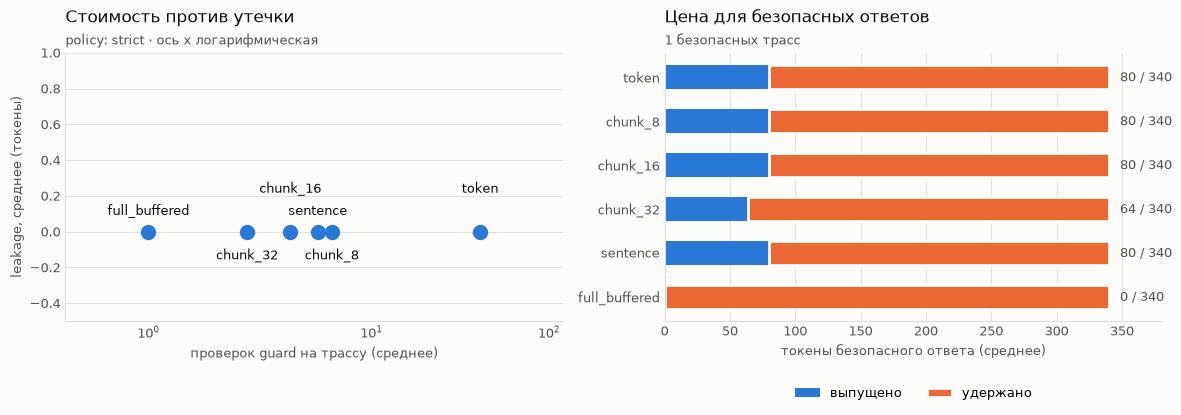

In [14]:
figure = plots.plot_cost_tradeoff(streaming_metrics, run.intervention_results, policy="strict")

Левая панель — это карта компромисса: режим полезен, если при сопоставимой утечке он требует заметно меньше проверок. Правая панель показывает обратную сторону буферизации: `full_buffered` ничего не выпускает до конца ответа, поэтому безопасный ответ полностью задерживается, а `token` отдаёт текст сразу.

В smoke-прогоне безопасная трасса заблокирована ошибочно, поэтому удержанными оказываются и те токены, которые следовало показать. Это ложноположительное срабатывание, а не свойство режима.

## Парное сравнение режимов

Режимы применяются к одним и тем же трассам, поэтому сравнивается разность метрики внутри каждой трассы. Для полного прогона преимущество режима утверждается только тогда, когда bootstrap CI разности не включает ноль.

In [15]:
paired = paired_mode_differences(run.intervention_results).round(3)
display(paired)

,policy,mode_a,mode_b,metric,mean_difference,ci_low,ci_high
0,conservative,chunk_16,chunk_32,leakage_tokens,0.0,0.0,0.0
1,conservative,chunk_16,chunk_8,leakage_tokens,0.0,0.0,0.0
2,conservative,chunk_16,full_buffered,leakage_tokens,0.0,0.0,0.0
3,conservative,chunk_16,sentence,leakage_tokens,0.0,0.0,0.0
4,conservative,chunk_16,token,leakage_tokens,0.0,0.0,0.0
5,conservative,chunk_32,chunk_8,leakage_tokens,0.0,0.0,0.0
6,conservative,chunk_32,full_buffered,leakage_tokens,0.0,0.0,0.0
7,conservative,chunk_32,sentence,leakage_tokens,0.0,0.0,0.0
8,conservative,chunk_32,token,leakage_tokens,0.0,0.0,0.0
9,conservative,chunk_8,full_buffered,leakage_tokens,0.0,0.0,0.0


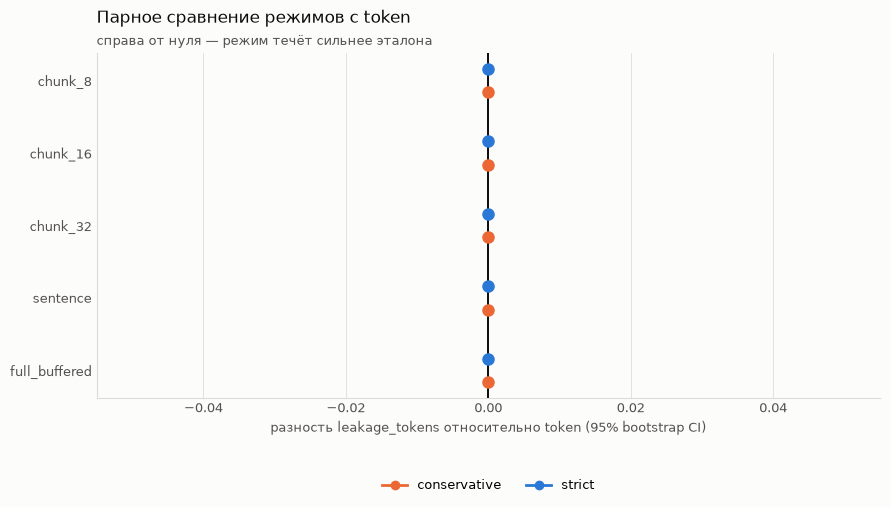

In [16]:
figure = plots.plot_paired_differences(paired, reference_mode="token")

График оставляет только сравнения с эталонным режимом (`reference_mode`), иначе пятнадцать пар на политику не читаются. Точка правее нуля означает, что режим выпускает больше опасных токенов, чем эталон; вертикальная линия нуля пересекает интервал — значит, разница не установлена.

## Вывод

Smoke-прогон успешно проходит все этапы и создаёт таблицы и графики. Следующий содержательный шаг — поставить `PROFILE = "full"`, выполнить notebook заново и повторить анализ уже на 210 трассах: сохранённого прогона для `full` нет, поэтому ячейка прогона сама запустит модель. Smoke-значения не следует переносить в итоговый отчёт как научные результаты.

На полном прогоне основная нагрузка ложится на четыре графика: смещение сигнала относительно onset, ECDF leakage, карта «стоимость против утечки» и парное сравнение с эталонным режимом. Остальные остаются диагностическими: матрицы ошибок объясняют доли, а трассовая временная шкала показывает отдельные аномалии вроде сигнала на первом токене.